In [1]:
import sys
from pathlib import Path

root = Path().resolve()
while root != root.parent:
    if (root / "src").exists():
        if str(root) not in sys.path:
            sys.path.insert(0, str(root))
        break
    root = root.parent

print("Project root added to path:", root)

Project root added to path: /Users/jonathanma/Desktop/MSEnotes/733_NPBayes/FinalProject/NPBS-project-MaZhu


In [2]:
from src.external_bridge.resolve_ipd_adapter import (
    resolve_available_objects,
    reconstruct_ipd_with_resolve,
)

resolve_available_objects()

['Any',
 'Dict',
 'Iterable',
 'KaplanMeierFitter',
 'List',
 'Optional',
 'Tuple',
 'Union',
 '_align_single_boundary',
 '_at_risk_count',
 '_km_survival_at',
 '_nextbefore',
 '_try_add_censors_in_bin',
 'get_ipd',
 'np',
 'pd']

In [3]:
from src.simulation.trial_generator import simulate_single_trial
from src.simulation.km_renderer import build_km_render_from_ipd

sim = simulate_single_trial(n=300, seed=733, trial_id="trial_test")
df_true = sim.ipd

render = build_km_render_from_ipd(df_true, time_col="time", event_col="event")

ipd_resolve = reconstruct_ipd_with_resolve(
    n=len(df_true),
    t=render.curve_points["time"].tolist(),
    S=render.curve_points["survival"].tolist(),
    cens_t=render.censor_points["time"].tolist(),
    random_state=733,
    debug=False,
)

ipd_resolve.head()

,time,event
0,0.042745,1
1,0.100326,1
2,0.154774,1
3,0.220988,1
4,0.331674,0


=== Reconstruction Comparison ===
        method  km_rmse  survival_diff_t0  n_true  n_recon
0         ours      0.0               0.0     300      300
1  resolve_ipd      0.0               0.0     300      300


,method,km_rmse,survival_diff_t0,n_true,n_recon
0,ours,0.0,0.0,300,300
1,resolve_ipd,0.0,0.0,300,300


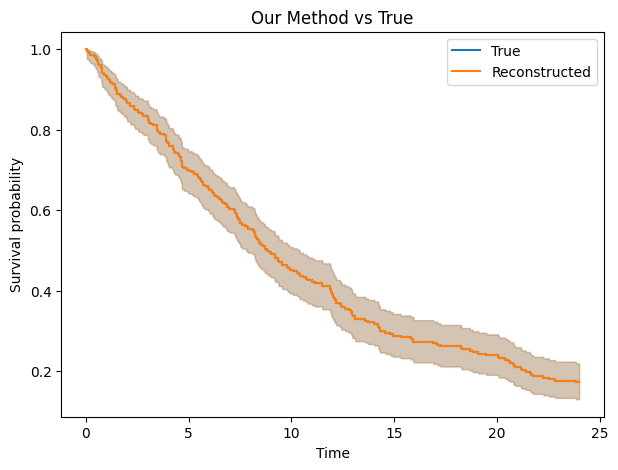

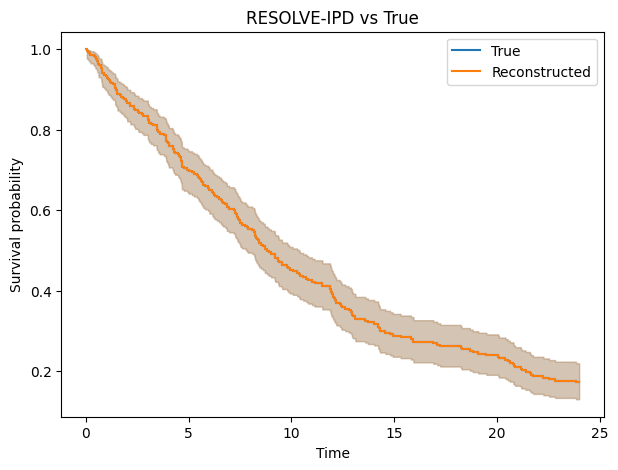

In [4]:
from src.simulation.trial_generator import simulate_single_trial
from src.simulation.km_renderer import build_km_render_from_ipd
from src.cen_km.reconstruct import reconstruct_ipd_with_censoring
from src.external_bridge.resolve_ipd_adapter import reconstruct_ipd_with_resolve
from src.validation.comparison import compare_and_plot

# simulate ground truth
sim = simulate_single_trial(n=300, seed=733)
df_true = sim.ipd

# build KM inputs
render = build_km_render_from_ipd(df_true, time_col="time", event_col="event")

# your method
ipd_ours = reconstruct_ipd_with_censoring(
    render.curve_points,
    render.censor_points,
    n_initial=len(df_true),
)

# resolve method
ipd_resolve = reconstruct_ipd_with_resolve(
    n=len(df_true),
    t=render.curve_points["time"].tolist(),
    S=render.curve_points["survival"].tolist(),
    cens_t=render.censor_points["time"].tolist(),
    random_state=733,
)

# compare
results, fig1, fig2 = compare_and_plot(df_true, ipd_ours.ipd, ipd_resolve)

results